In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import scanpy as sc
import anndata as ad

In [23]:
PROJECT_ROOT = Path.cwd().resolve().parent
input_file = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "uppl1541_filtered_feature_bc_matrix.h5"
)

if not input_file.exists():
    raise FileNotFoundError(f"Input file not found: {input_file}")

output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

plot_dir = PROJECT_ROOT / "results" / "UPPL1541_mouse_analysis" / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

In [24]:
adata_preprocessing = sc.read_10x_h5(input_file)
adata_preprocessing.var_names_make_unique()
adata_preprocessing.obs_names_make_unique()
adata_preprocessing.obs["sample"] = "UPPL1541_VEH"

# Saving count data
adata_preprocessing.layers["counts"] = adata_preprocessing.X.copy()

/Users/timothy/miniconda3/envs/python-311/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/timothy/miniconda3/envs/python-311/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [25]:
adata_preprocessing.shape

(10896, 33696)

Preprocessing

In [26]:
adata_preprocessing.var["mt"] = adata_preprocessing.var_names.str.startswith("mt-")
adata_preprocessing.var["ribo"] = adata_preprocessing.var_names.str.startswith(("Rps", "Rpl"))
adata_preprocessing.var["hb"] = adata_preprocessing.var_names.str.contains(r"^Hb[ab]", regex=True)

sc.pp.calculate_qc_metrics(adata_preprocessing, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

Visualize metrics

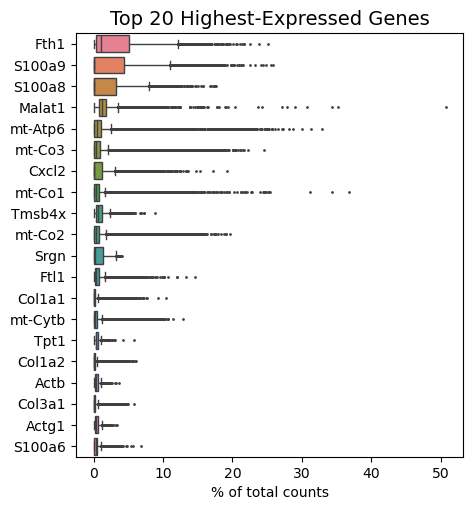

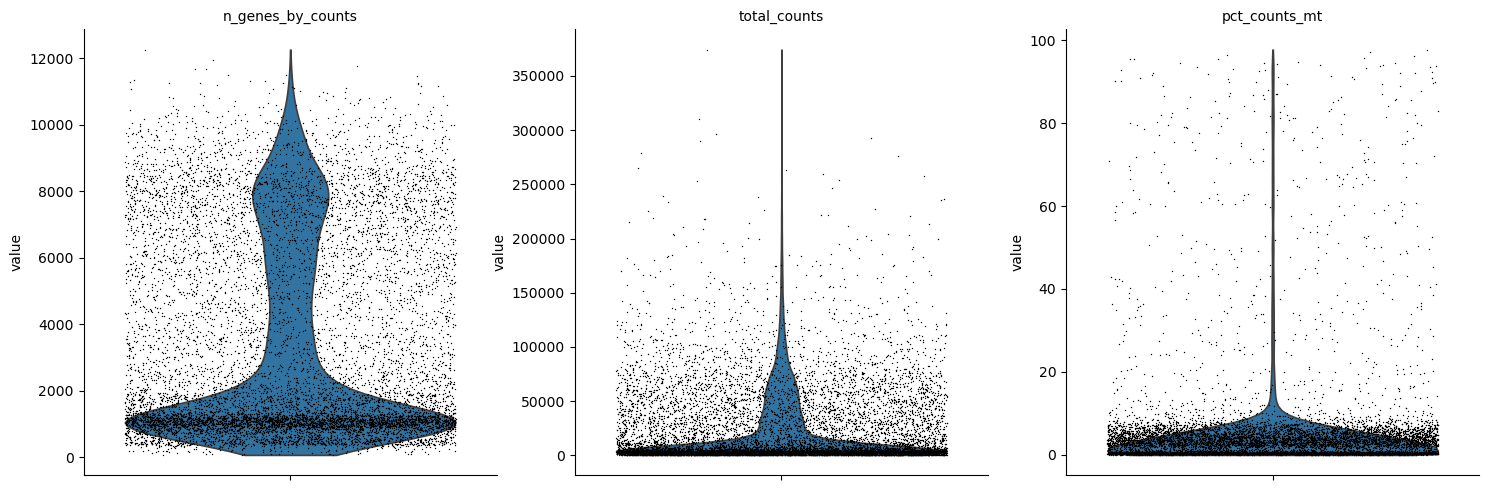

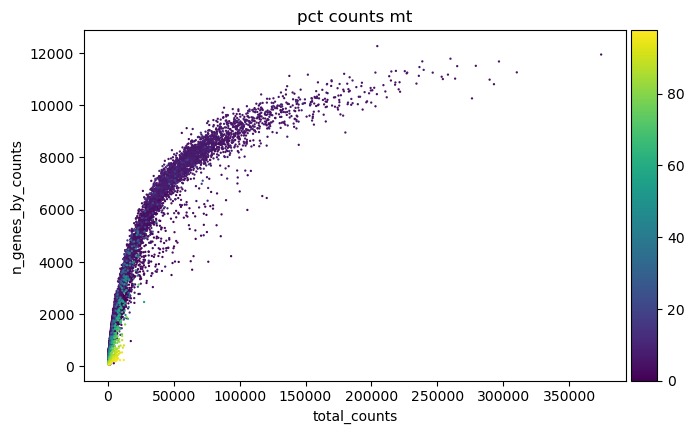

In [27]:
ax = sc.pl.highest_expr_genes(adata_preprocessing, n_top=20, show=False)
ax.set_title("Top 20 Highest-Expressed Genes", fontsize=14)

# Genes by counts
# Total Counts
# % Mitochondria
sc.pl.violin(
    adata_preprocessing,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

# 
sc.pl.scatter(adata_preprocessing, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [28]:
sc.pp.filter_cells(adata_preprocessing, min_genes=100) # filter out cells with <100 genes expressed
sc.pp.filter_genes(adata_preprocessing, min_cells=3) # filter out genes that are expressed in <3 cells
sc.pp.scrublet(adata_preprocessing) # scrublet to identify doublets
adata_preprocessing = adata_preprocessing[adata_preprocessing.obs["doublet_score"] < 0.25] # filter out cells with high doublet scores
adata_preprocessing = adata_preprocessing[adata_preprocessing.obs["pct_counts_mt"] < 10].copy() # filter out cells with high mt gene expression (revisit, may be real biology)

Normalization

In [29]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_preprocessing)

# Logarithmize the data
sc.pp.log1p(adata_preprocessing)
adata_preprocessing.raw = adata_preprocessing.copy()

Feature Selection

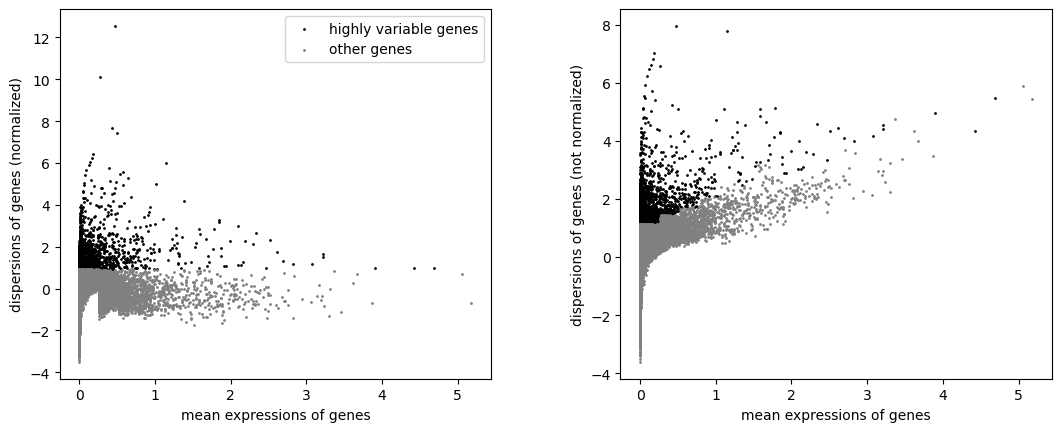

In [61]:
sc.pp.highly_variable_genes(
    adata_preprocessing,
    flavor="seurat",
    n_top_genes=3000,
    subset=False
)
sc.pl.highly_variable_genes(adata_preprocessing)

Dimensionality Reduction

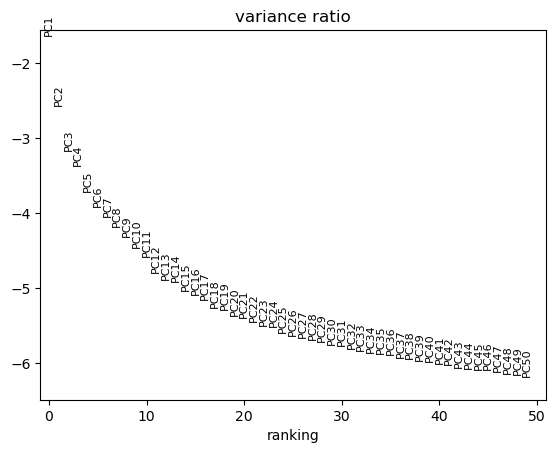

In [62]:
sc.pp.pca(
    adata_preprocessing,
    n_comps=50,
    mask_var="highly_variable",
    svd_solver="arpack",
    random_state=42
)

# Choose 50 PCs for downstream analysis
sc.pl.pca_variance_ratio(
    adata_preprocessing,
    n_pcs=50,
    log=True
)

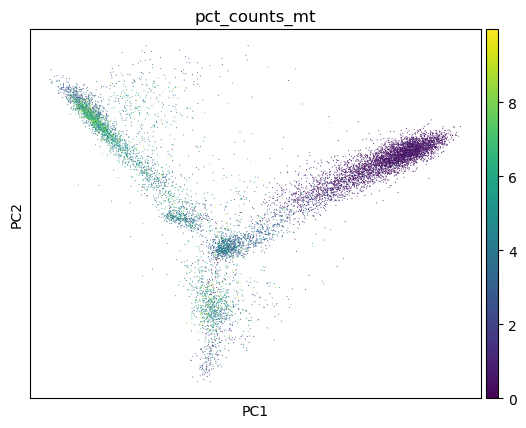

In [63]:
sc.pl.pca(
    adata_preprocessing,
    color=["pct_counts_mt"],
    ncols=2,
    size=2,
)

In [64]:
sc.pp.neighbors(adata_preprocessing, n_pcs=50)
sc.tl.umap(adata_preprocessing)

Clustering

In [65]:
# Chose 0.20 because it gives a reasonable number of clusters (9) and is consistent with the literature for this dataset
# 0.50 is also included for comparison for higher granularity clustering
for resolution in [0.2,0.30]:
    cluster_key = f"leiden_res_{resolution:.2f}"

    sc.tl.leiden(
        adata_preprocessing,
        resolution=resolution,
        key_added=cluster_key,
        flavor="igraph",
        n_iterations=2,
        directed=False,
        random_state=42
    )

    print(
        cluster_key,
        adata_preprocessing.obs[cluster_key].nunique(),
        "clusters"
    )

leiden_res_0.20 11 clusters
leiden_res_0.30 14 clusters


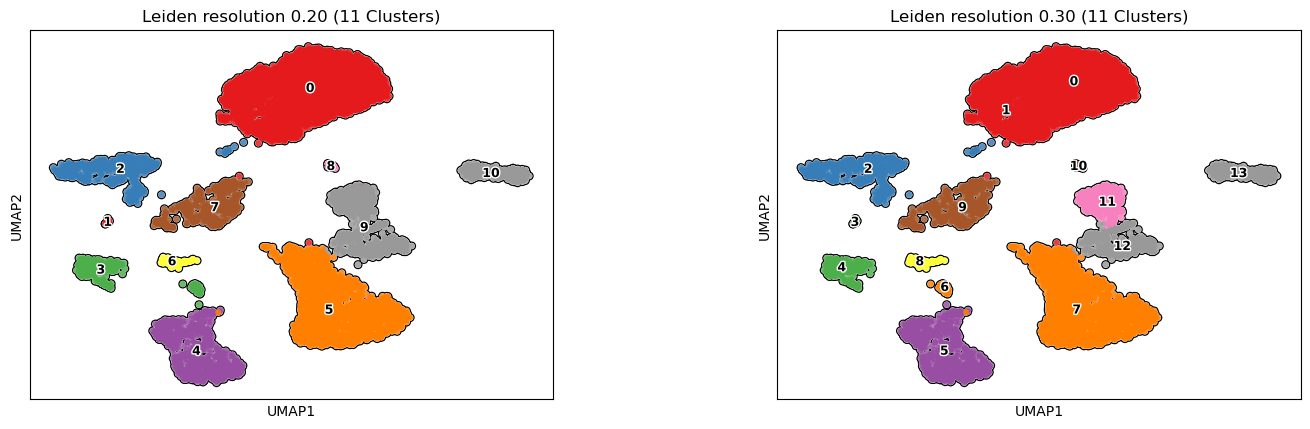

In [66]:
sc.pl.umap(
    adata_preprocessing,
    color=["leiden_res_0.20", "leiden_res_0.30"],
    title=["Leiden resolution 0.20 (11 Clusters)", "Leiden resolution 0.30 (11 Clusters)"],
    legend_loc="on data",
    legend_fontsize=9,
    legend_fontweight="semibold",
    legend_fontoutline=2,
    size=20,
    alpha=0.85,
    marker="o",
    add_outline=True,
    outline_width=(0.2, 0.03),
    palette="Set1",
    ncols=2,
    wspace=0.3
)

Re-asses QC and cell filtering

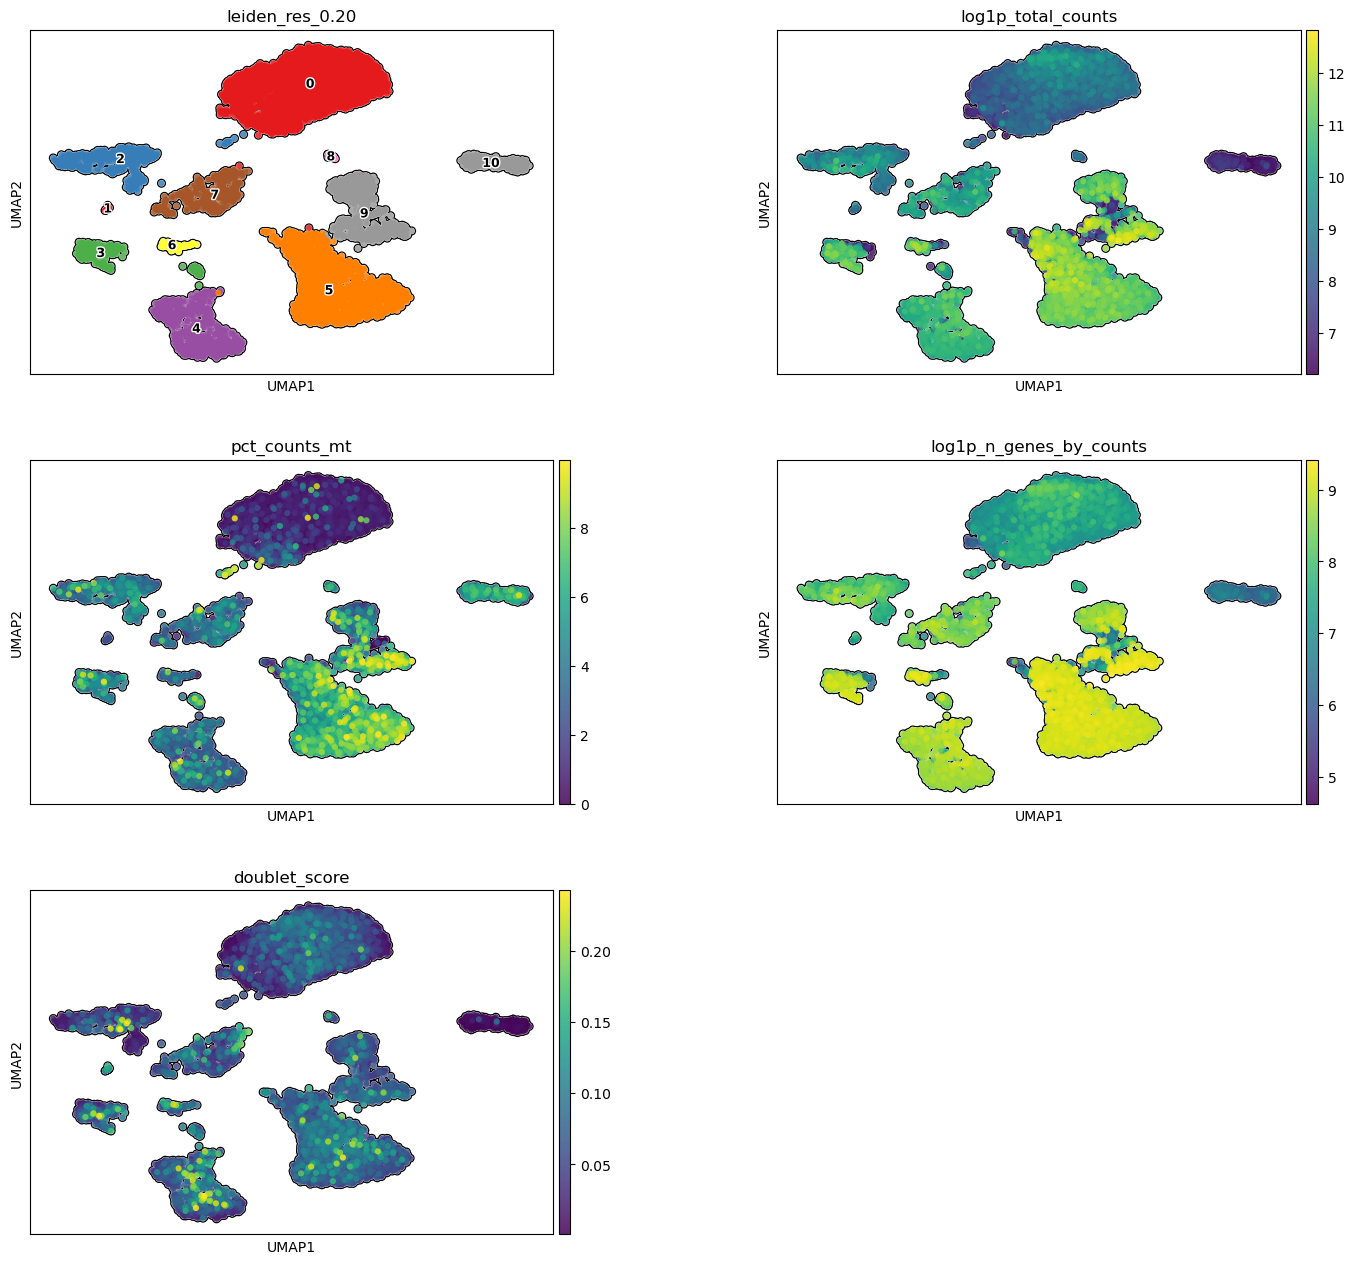

In [67]:
sc.pl.umap(
    adata_preprocessing,
    color=["leiden_res_0.20", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts", "doublet_score"],
    wspace=0.3,
    ncols=2,
    legend_loc="on data",
    legend_fontsize=9,
    legend_fontweight="semibold",
    legend_fontoutline=2,
    size=20,
    alpha=0.85,
    marker="o",
    add_outline=True,
    outline_width=(0.2, 0.03),
    palette="Set1"
)

In [37]:
adata_preprocessing.write_h5ad(output_dir / "uppl1541_processed_unlabeled.h5ad")

Cell Type Annotation

In [68]:
adata = adata_preprocessing.copy()

In [69]:
# keys: cell types or populations, values: lists of marker genes

# For subsetting to only leukocytes, which are the main immune cells of interest
leukocyte_markers = {
    "Leukocytes": [
        "Ptprc",
        "Cd52",
        "Coro1a",
        "Lcp1",
        "Ptpn6",
        "Rac2",
        "Hcls1"
    ]
}

immune_cell_markers = {
    "Neutrophils_Granulocytes": [
        "Ly6g", "Csf3r", "Retnlg", "Ngp",
        "Camp", "S100a8", "S100a9", "Mmp8"
    ],

    "Macrophages": [
        "C1qa", "C1qb", "C1qc", "Mertk",
        "Fcgr1", "Adgre1", "Apoe", "Ms4a7",
        "Csf1r", "Cd68"
    ],

    "Monocytes": [
        "Ly6c2", "Ccr2", "Plac8", "Sell",
        "S100a8", "S100a9", "Chil3", "Fn1"
    ],

    "B_Cells": [
        "Cd79a", "Cd79b", "Ms4a1",
        "Cd22", "Bank1", "Pax5", "Ebf1"
    ],

    "CD8_T_Cells": [
        "Cd8a", "Cd8b1", "Ccl5", "Gzmk",
        "Nkg7", "Prf1", "Gzmb"
    ],

    "CD4_T_Cells": [
        "Cd4", "Il7r", "Ccr7", "Ltb",
        "Tcf7", "Lef1", "Mal"
    ],

    "Other_CD3_T_Cells": [
        "Cd3d", "Cd3e", "Cd3g", "Trac",
        "Trbc1", "Trbc2", "Lck", "Lat"
    ]
}

#from previous analysis
# cluster_labels = {
#     "0": "UNKNOWN",
#     "1": "UNKNOWN",
#     "2": "Fibroblasts",
#     "3": "Neutrophils",
#     "4": "UNKNOWN",
#     "5": "Tumor Urothelial",
#     "6": "Macrophages",
#     "7": "Endothelial",
#     "8": "T Cells"
# }

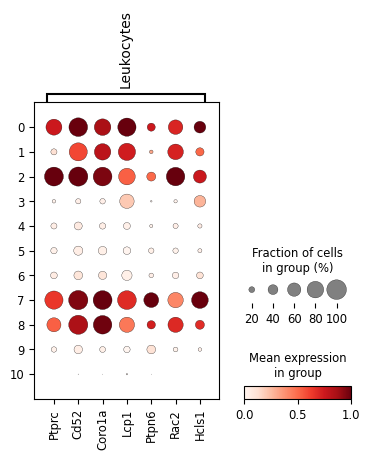

categories: 0, 1, 2, etc.
var_group_labels: Leukocytes


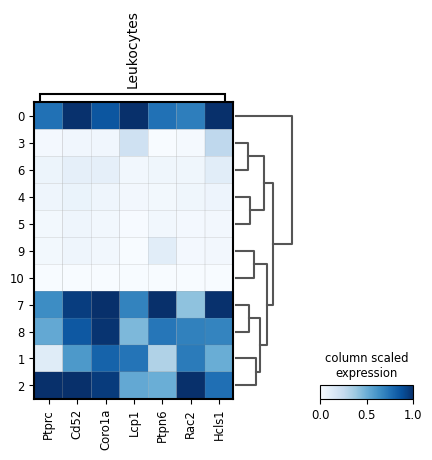

In [70]:
sc.pl.dotplot(adata, leukocyte_markers, groupby="leiden_res_0.20", standard_scale="var")
sc.pl.matrixplot(
    adata,
    leukocyte_markers,
    "leiden_res_0.20",
    dendrogram=True,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
)

In [73]:
adata_leukocytes = adata[
    adata.obs["leiden_res_0.20"]
    .astype(str)
    .isin(["0","1","2","7","8"])
].copy()

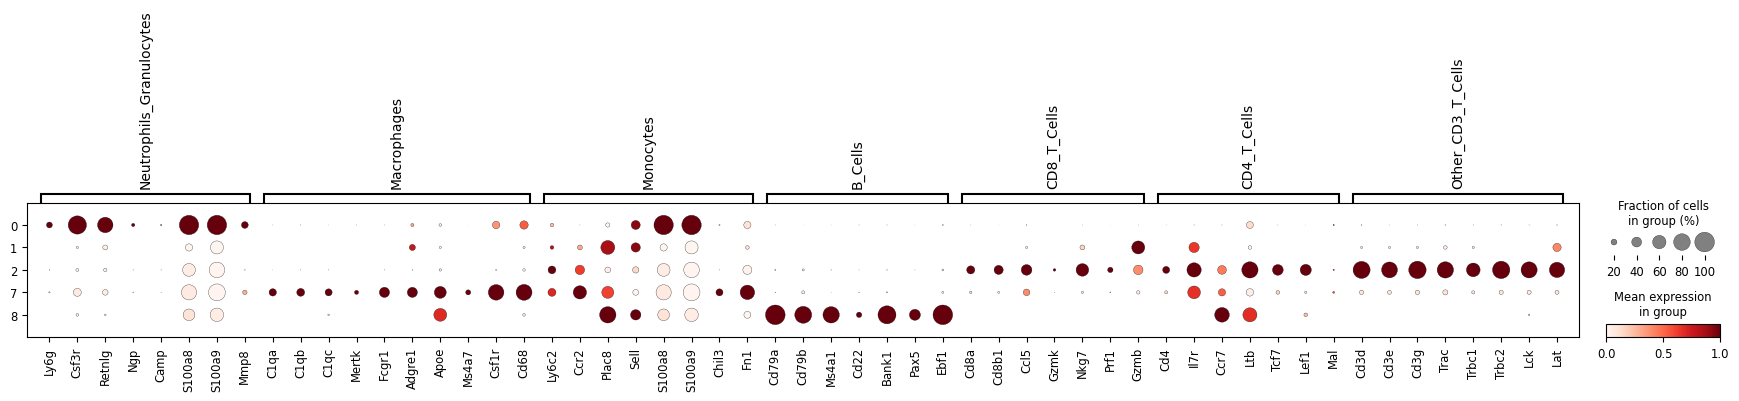

In [75]:
sc.pl.dotplot(adata_leukocytes, immune_cell_markers, groupby="leiden_res_0.20", standard_scale="var")

leukocyte_labels = {
    "0": "Neutrophils",
    "1": "Monocytes",
    "2": "T Cells",
    "7": "Macrophages",
    "8": "B Cells"
}

adata_leukocytes.obs["cell_type"] = (
    adata_leukocytes.obs["leiden_res_0.20"]
    .astype(str)
    .map(leukocyte_labels)
    .fillna("Unassigned")
    .astype("category")
)

In [76]:
n_macrophages = (
    adata_leukocytes.obs["cell_type"] == "Macrophages"
).sum()

n_leukocytes = adata_leukocytes.n_obs

macrophage_percentage = 100 * n_macrophages / n_leukocytes

print(f"Macrophages: {n_macrophages}")
print(f"Total leukocytes: {n_leukocytes}")
print(f"Macrophage percentage: {macrophage_percentage:.2f}%")

Macrophages: 489
Total leukocytes: 5804
Macrophage percentage: 8.43%


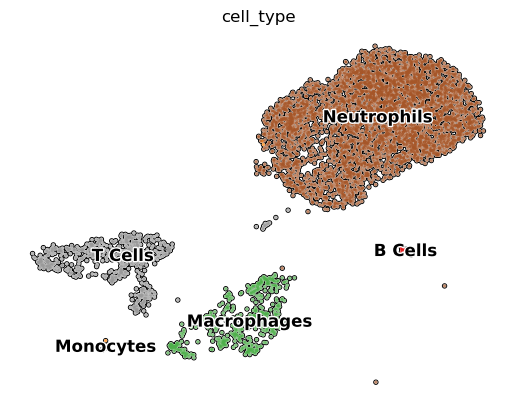

In [77]:
sc.pl.umap(
    adata_leukocytes,
    color=["cell_type"],
    legend_loc="on data", wspace=0.4,
    add_outline=True, palette="Set1", 
    legend_fontsize=12,legend_fontoutline=2,
    frameon=False
)

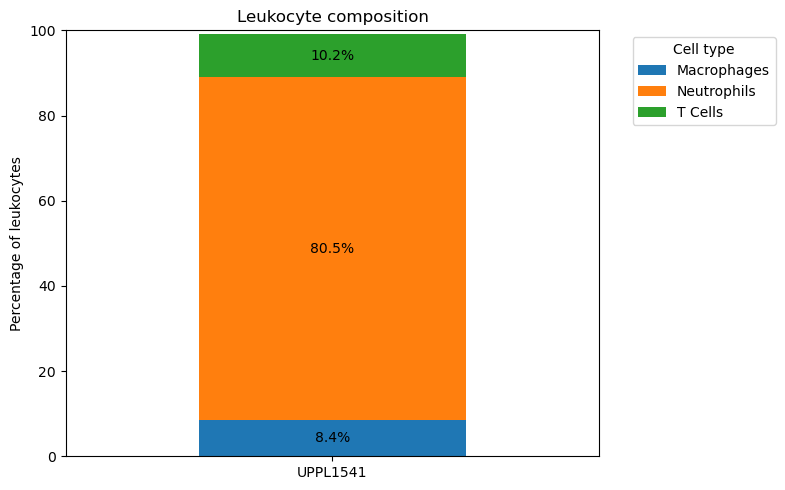

In [78]:
cell_type_order = [
    "Macrophages",
    "Neutrophils",
    "T Cells"
]

plot_data = (
    adata_leukocytes.obs["cell_type"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(cell_type_order, fill_value=0)
    .to_frame()
    .T
)

plot_data.index = ["UPPL1541"]

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 3 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10
    )

ax.set_xlabel("")
ax.set_ylabel("Percentage of leukocytes")
ax.set_title("Leukocyte composition")
ax.set_ylim(0, 100)

ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [79]:
# Proportion of leukocytes in the total cell population
adata_leukocytes.n_obs / adata.n_obs

0.570978848991638

In [74]:
adata_leukocytes.obs["sample"] = "UPPL1541"
adata_leukocytes.write_h5ad(output_dir / "uppl1541_leukocytes_only.h5ad")